# 8. The method of least squares

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt 
import math
from sklearn.linear_model import LinearRegression
import seaborn as sns

### 1. Тест на твердость по Янке

In [2]:
df_density_hardness = pd.read_excel('density and hardness.xlsx')

In [3]:
df_density_hardness

,density,hardness
0,24.7,484
1,24.8,427
2,27.3,413
3,28.4,517
4,28.4,549
5,29.0,648
6,30.3,587
7,32.7,704
8,35.6,979
9,38.5,914


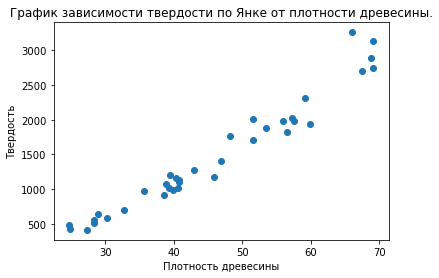

In [4]:
plt.scatter(x=df_density_hardness['density'], y=df_density_hardness['hardness'])
plt.title("График зависимости твердости по Янке от плотности древесины.")
plt.ylabel("Твердость")
plt.xlabel("Плотность древесины")
plt.savefig('density_and_hardness', dpi = 200, transparent=True, bbox_inches = 'tight');

Разделяем переменные

In [6]:
x = df_density_hardness['density'].values.reshape(-1, 1)
y = df_density_hardness['hardness'].values

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)
print('Slope: {:.2f}'.format(model.coef_[0]))
print('Intercept: {:.2f}'.format(model.intercept_))

Slope: 57.51
Intercept: -1160.50


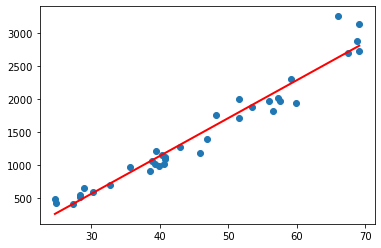

In [8]:
plt.scatter(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2);
plt.savefig('linear_regression_density_and_hardness', dpi = 200, transparent=True, bbox_inches = 'tight');

Гистограмма остаточных и подобранных значений

In [9]:
residuals = df_density_hardness['hardness'] - (model.coef_[0] * df_density_hardness['density'] + model.intercept_)

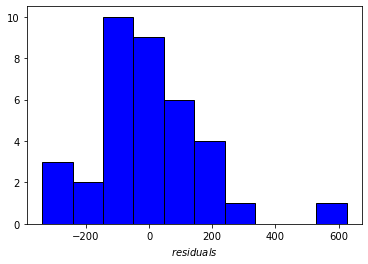

In [10]:
plt.hist(residuals, color = 'blue', edgecolor = 'black')
plt.xlabel('$residuals$');
plt.savefig('hist_residuals', dpi = 200, transparent=True, bbox_inches = 'tight')

Одно из ключевых предположений линейной регрессии состоит в том, что остатки регрессионной модели примерно нормально распределены и гомоскедастичны на каждом уровне объясняющей переменной.

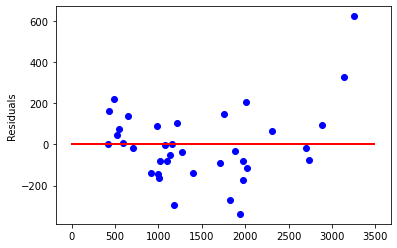

In [11]:
plt.scatter(y,  df_density_hardness['hardness'] - (model.coef_[0] * df_density_hardness['density'] + model.intercept_),
            c='blue', marker='o', label='Training data')
plt.ylabel('Residuals')
plt.hlines(y=0, xmin=-10, xmax=3500, lw=2, color='red')
plt.savefig('residuals', dpi = 200, transparent=True, bbox_inches = 'tight');